/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

(np.float64(-0.5), np.float64(3466.5), np.float64(1293.5), np.float64(-0.5))

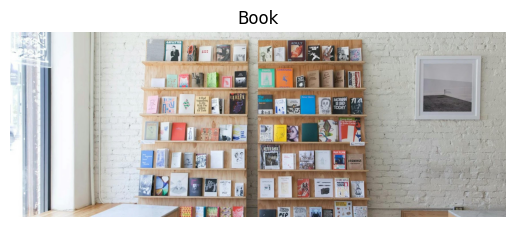

In [2]:
import matplotlib.pyplot as plt
from PIL import Image
import requests
from io import BytesIO
from datasets import load_dataset

def load_image(url):
    response = requests.get(url)
    return Image.open(BytesIO(response.content)).convert("RGB")

# Load the dataset and get the first example
ds = load_dataset("allenai/pixmo-points", split="train", streaming=True)
example = next(iter(ds))

img = load_image(example["image_url"])

plt.imshow(img)
plt.title(example["label"])
plt.axis("off")

Keys: dict_keys(['image_url', 'image_sha256', 'points', 'count', 'label', 'collection_method'])
Label: Book
Collection method: counting
Number of GT points: 91
Image URL: https://infatuation.imgix.net/media/images/guides/coffee-shops-with-really-fast-wi-fi/banners/1625003769.8128223.png
Image size: (3467, 1294)
First GT pixel point: (1025, 153)

Prompts:
- book
- point to the book
- pick up the book
- point to where you would grasp the book

Predictions:
book -> (1752, 658)
point to the book -> (1693, 641)
pick up the book -> (1728, 609)
point to where you would grasp the book -> (1759, 617)

Distance to first GT point:
book                                     error = 885.19
point to the book                        error = 827.27
pick up the book                         error = 837.94
point to where you would grasp the book  error = 868.36

Aggregated prediction: (1733, 631)
Aggregated error: 854.25


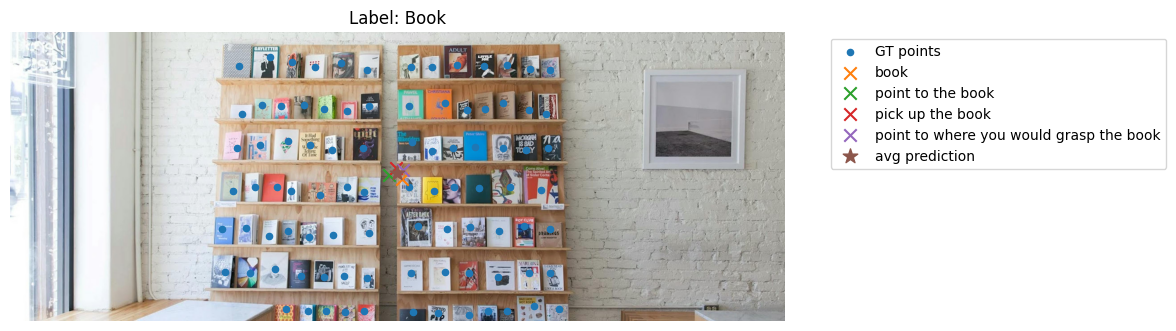

In [3]:
# =========================
# 1) Install dependencies
# =========================
!pip install -q datasets pillow matplotlib requests

# =========================
# 2) Imports
# =========================
from datasets import load_dataset
import requests
from PIL import Image
from io import BytesIO
import matplotlib.pyplot as plt
import math
import random

# =========================
# 3) Load one PixMo sample
# =========================
ds = load_dataset("allenai/pixmo-points", split="train", streaming=True)

example = next(iter(ds))   # take just one sample
print("Keys:", example.keys())
print("Label:", example["label"])
print("Collection method:", example.get("collection_method"))
print("Number of GT points:", len(example["points"]))
print("Image URL:", example["image_url"])

# =========================
# 4) Load image from URL
# =========================
def load_image(url):
    response = requests.get(url, timeout=20)
    response.raise_for_status()
    return Image.open(BytesIO(response.content)).convert("RGB")

img = load_image(example["image_url"])
w, h = img.size
print("Image size:", (w, h))

# =========================
# 5) Convert normalized GT points to pixel points
#    PixMo stores points in 0-100 normalized coordinates
# =========================
def normalized_to_pixel(pt, width, height):
    x_pix = int(pt["x"] / 100.0 * width)
    y_pix = int(pt["y"] / 100.0 * height)
    return (x_pix, y_pix)

gt_points_pixel = [normalized_to_pixel(pt, w, h) for pt in example["points"]]

# Use first GT point for simple evaluation
gt_x, gt_y = gt_points_pixel[0]
print("First GT pixel point:", (gt_x, gt_y))

# =========================
# 6) Define multiple prompts for same sample
# =========================
def get_prompts(label):
    label_lower = label.lower()
    return [
        label_lower,
        f"point to the {label_lower}",
        f"pick up the {label_lower}",
        f"point to where you would grasp the {label_lower}",
    ]

prompts = get_prompts(example["label"])
print("\nPrompts:")
for p in prompts:
    print("-", p)

# =========================
# 7) Placeholder Molmo inference function
#    Replace this later with actual Molmo code
# =========================
def run_molmo(image, prompt):
    """
    Placeholder function.
    Replace this with your real Molmo inference.

    Must return (x, y) in PIXEL coordinates.
    """
    width, height = image.size

    # Dummy prediction near image center with slight randomness
    x = width // 2 + random.randint(-40, 40)
    y = height // 2 + random.randint(-40, 40)
    x = max(0, min(width - 1, x))
    y = max(0, min(height - 1, y))
    return (x, y)

# =========================
# 8) Run all prompts on same image
# =========================
predictions = []
for prompt in prompts:
    pred_xy = run_molmo(img, prompt)
    predictions.append({
        "prompt": prompt,
        "pred_xy": pred_xy
    })

print("\nPredictions:")
for item in predictions:
    print(item["prompt"], "->", item["pred_xy"])

# =========================
# 9) Simple distance metric
# =========================
def euclidean_distance(p1, p2):
    return math.sqrt((p1[0] - p2[0])**2 + (p1[1] - p2[1])**2)

print("\nDistance to first GT point:")
for item in predictions:
    err = euclidean_distance(item["pred_xy"], (gt_x, gt_y))
    print(f"{item['prompt']:<40} error = {err:.2f}")

# =========================
# 10) Aggregate predictions across prompts
#     (simple average)
# =========================
def average_point(points):
    xs = [p[0] for p in points]
    ys = [p[1] for p in points]
    return (int(sum(xs) / len(xs)), int(sum(ys) / len(ys)))

all_pred_points = [item["pred_xy"] for item in predictions]
avg_pred = average_point(all_pred_points)
avg_err = euclidean_distance(avg_pred, (gt_x, gt_y))

print("\nAggregated prediction:", avg_pred)
print("Aggregated error:", round(avg_err, 2))

# =========================
# 11) Visualize image with GT and predictions
# =========================
plt.figure(figsize=(10, 8))
plt.imshow(img)

# Plot all GT points in green
gt_xs = [p[0] for p in gt_points_pixel]
gt_ys = [p[1] for p in gt_points_pixel]
plt.scatter(gt_xs, gt_ys, s=20, marker='o', label='GT points')

# Plot each prompt prediction
for item in predictions:
    x, y = item["pred_xy"]
    plt.scatter(x, y, s=80, marker='x', label=item["prompt"])

# Plot aggregated prediction
plt.scatter(avg_pred[0], avg_pred[1], s=120, marker='*', label='avg prediction')

plt.title(f'Label: {example["label"]}')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.axis("off")
plt.show()